<a href="https://colab.research.google.com/github/mohgeb/GlycemicPlus/blob/main/04_ground_truth_validation_and_replay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score
)

PROJECT = Path(
    "/content/drive/MyDrive/GlycemicSentinel"
)

RESULT_DIR = PROJECT / "results"

COMPARISON_FILE = (
    RESULT_DIR /
    "hybrid_ground_truth_comparison.csv"
)

print("Comparison file:", COMPARISON_FILE)
print("Exists:", COMPARISON_FILE.exists())

Mounted at /content/drive
Comparison file: /content/drive/MyDrive/GlycemicSentinel/results/hybrid_ground_truth_comparison.csv
Exists: True


In [ ]:
df = pd.read_csv(
    COMPARISON_FILE
)

print("Rows:", len(df))
print("Columns:")

for column in df.columns:
    print(" -", column)

display(df.head())

Rows: 3844
Columns:
 - std
 - rms
 - iqr
 - ptp
 - skew
 - kurtosis
 - diff_std
 - diff_abs_mean
 - num_peaks
 - mean_ibi
 - sdnn
 - rmssd
 - estimated_hr
 - power_0_5_1
 - power_1_2
 - power_2_4
 - power_4_8
 - dominant_frequency
 - subject
 - row
 - glucose
 - label
 - timestamp_ns
 - split
 - actual_label
 - predicted_code
 - predicted_label
 - p_hypo
 - p_normal
 - p_hyper
 - correct
 - confidence
 - actual_probability


,std,rms,iqr,ptp,skew,kurtosis,diff_std,diff_abs_mean,num_peaks,mean_ibi,...,split,actual_label,predicted_code,predicted_label,p_hypo,p_normal,p_hyper,correct,confidence,actual_probability
0,2.251554,2.251787,1.352336,32.317026,0.024663,9.520369,0.364328,0.209944,456,0.662612,...,test,In Range,2,Hyperglycemia,0.277782,0.360064,0.362153,False,0.362153,0.360064
1,2.749314,2.749464,1.345052,43.675135,-0.323701,11.295116,0.467344,0.249435,454,0.642247,...,test,In Range,2,Hyperglycemia,0.282950,0.353212,0.363838,False,0.363838,0.353212
2,3.063152,3.063524,1.360311,77.046862,-0.550564,26.263465,0.530065,0.265460,453,0.668242,...,test,In Range,2,Hyperglycemia,0.304810,0.344584,0.350606,False,0.350606,0.344584
3,2.401984,2.401995,1.352245,35.694448,-0.377589,7.253631,0.434706,0.249291,401,0.643243,...,test,Hypoglycemia,1,In Range,0.286713,0.357073,0.356214,False,0.357073,0.286713
4,1.764423,1.764427,1.350855,33.328836,-0.133925,10.452287,0.314854,0.189520,438,0.655843,...,test,Hypoglycemia,2,Hyperglycemia,0.281818,0.356810,0.361372,False,0.361372,0.281818


In [ ]:
LABEL_NAMES = {
    0: "Hypoglycemia",
    1: "In Range",
    2: "Hyperglycemia"
}

# Make sure labels are numeric
df["label"] = df["label"].astype(int)
df["predicted_code"] = df["predicted_code"].astype(int)

# Recreate names to make sure they are consistent
df["actual_label"] = (
    df["label"]
    .map(LABEL_NAMES)
)

df["predicted_label"] = (
    df["predicted_code"]
    .map(LABEL_NAMES)
)

# Convert timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp_ns"],
    unit="ns",
    errors="coerce"
)

# Model confidence
df["confidence"] = df[
    ["p_hypo", "p_normal", "p_hyper"]
].max(axis=1)

# Was prediction correct?
df["correct"] = (
    df["label"]
    ==
    df["predicted_code"]
)

print("Rows:", len(df))
print("Subjects:", df["subject"].nunique())
print("Missing glucose:", df["glucose"].isna().sum())
print("Missing timestamps:", df["timestamp"].isna().sum())

print("\nActual class counts:")
print(
    df["actual_label"]
    .value_counts()
)

Rows: 3844
Subjects: 10
Missing glucose: 0
Missing timestamps: 0

Actual class counts:
actual_label
In Range         3277
Hyperglycemia     359
Hypoglycemia      208
Name: count, dtype: int64


In [ ]:
y_true = df["label"].to_numpy()
y_pred = df["predicted_code"].to_numpy()

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

accuracy = (
    y_true == y_pred
).mean()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Hypoglycemia",
            "In Range",
            "Hyperglycemia"
        ],
        digits=4,
        zero_division=0
    )
)

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print(
    "Balanced Accuracy:",
    round(balanced_acc, 4)
)

               precision    recall  f1-score   support

 Hypoglycemia     0.3077    0.0769    0.1231       208
     In Range     0.8537    0.5679    0.6821      3277
Hyperglycemia     0.1110    0.4986    0.1816       359

     accuracy                         0.5349      3844
    macro avg     0.4241    0.3811    0.3289      3844
 weighted avg     0.7548    0.5349    0.6051      3844

Accuracy: 0.5349
Macro F1: 0.3289
Balanced Accuracy: 0.3811


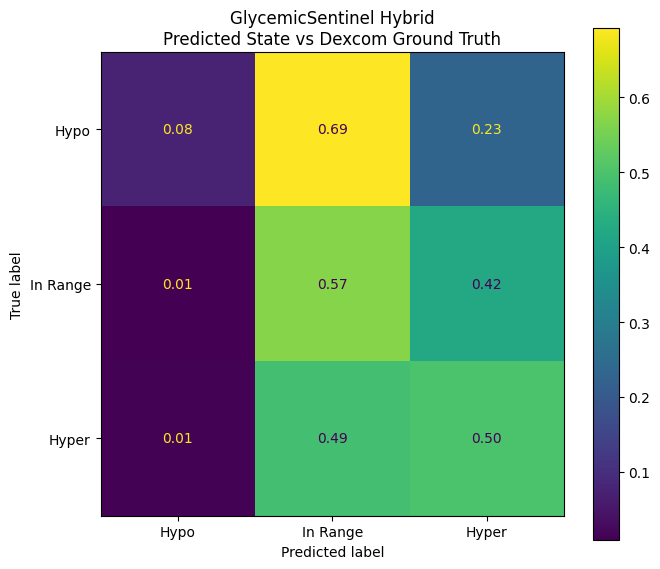

In [ ]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,

    display_labels=[
        "Hypo",
        "In Range",
        "Hyper"
    ],

    normalize="true",
    values_format=".2f",

    ax=ax
)

plt.title(
    "GlycemicSentinel Hybrid\n"
    "Predicted State vs Dexcom Ground Truth"
)

plt.tight_layout()
plt.show()

In [ ]:
probabilities = {
    0: df["p_hypo"].to_numpy(),
    1: df["p_normal"].to_numpy(),
    2: df["p_hyper"].to_numpy()
}

rows = []

for class_id, class_name in LABEL_NAMES.items():

    binary_truth = (
        y_true == class_id
    ).astype(int)

    prob = probabilities[class_id]

    auroc = roc_auc_score(
        binary_truth,
        prob
    )

    auprc = average_precision_score(
        binary_truth,
        prob
    )

    prevalence = binary_truth.mean()

    rows.append({
        "class": class_name,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Prevalence": prevalence
    })


discrimination_df = pd.DataFrame(rows)

display(
    discrimination_df.round(4)
)

,class,AUROC,AUPRC,Prevalence
0,Hypoglycemia,0.6005,0.1250,0.0541
1,In Range,0.4821,0.8495,0.8525
2,Hyperglycemia,0.5269,0.0970,0.0934


In [ ]:
subject_results = []

for subject, subject_df in df.groupby("subject"):

    true = (
        subject_df["label"]
        .to_numpy()
    )

    pred = (
        subject_df["predicted_code"]
        .to_numpy()
    )

    subject_results.append({
        "subject": subject,

        "samples":
            len(subject_df),

        "macro_f1":
            f1_score(
                true,
                pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                true,
                pred
            ),

        "accuracy":
            (true == pred).mean(),

        "hypo_windows":
            int((true == 0).sum()),

        "hyper_windows":
            int((true == 2).sum())
    })


subject_results = pd.DataFrame(
    subject_results
)

display(
    subject_results.round(4)
)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,subject,samples,macro_f1,balanced_accuracy,accuracy,hypo_windows,hyper_windows
0,c1s01,319,0.2803,0.3698,0.7210,8,0
1,c1s02,389,0.3415,0.5312,0.5681,0,96
2,c1s03,383,0.2819,0.3744,0.4465,4,62
3,c1s04,322,0.3801,0.5243,0.3975,0,52
4,c1s05,412,0.2642,0.3394,0.5850,34,8
5,c2s01,443,0.3549,0.4092,0.5824,20,47
6,c2s02,315,0.3170,0.4199,0.5302,93,0
7,c2s03,331,0.3295,0.3301,0.6647,2,77
8,c2s04,471,0.1624,0.4253,0.2866,8,10
9,c2s05,459,0.2722,0.3705,0.6209,39,7


In [ ]:
subject_results.to_csv(
    RESULT_DIR /
    "hybrid_subject_performance.csv",
    index=False
)

In [ ]:
comparison_table = df[
    [
        "subject",
        "timestamp",
        "glucose",
        "actual_label",
        "predicted_label",
        "p_hypo",
        "p_normal",
        "p_hyper",
        "confidence",
        "correct"
    ]
].copy()

display(
    comparison_table.head(25)
)

,subject,timestamp,glucose,actual_label,predicted_label,p_hypo,p_normal,p_hyper,confidence,correct
0,c1s01,2022-06-26 09:20:03,87.0,In Range,Hyperglycemia,0.277782,0.360064,0.362153,0.362153,False
1,c1s01,2022-06-26 09:25:03,80.0,In Range,Hyperglycemia,0.282950,0.353212,0.363838,0.363838,False
2,c1s01,2022-06-26 09:30:03,73.0,In Range,Hyperglycemia,0.304810,0.344584,0.350606,0.350606,False
3,c1s01,2022-06-26 09:35:03,66.0,Hypoglycemia,In Range,0.286713,0.357073,0.356214,0.357073,False
4,c1s01,2022-06-26 09:40:03,63.0,Hypoglycemia,Hyperglycemia,0.281818,0.356810,0.361372,0.361372,False
5,c1s01,2022-06-26 09:45:03,63.0,Hypoglycemia,Hyperglycemia,0.260202,0.356213,0.383586,0.383586,False
6,c1s01,2022-06-26 09:50:03,73.0,In Range,In Range,0.261683,0.384061,0.354256,0.384061,True
7,c1s01,2022-06-26 09:55:03,89.0,In Range,Hyperglycemia,0.279195,0.354013,0.366792,0.366792,False
8,c1s01,2022-06-26 10:00:04,117.0,In Range,In Range,0.269283,0.369953,0.360764,0.369953,True
9,c1s01,2022-06-26 10:05:04,142.0,In Range,Hyperglycemia,0.273326,0.363331,0.363343,0.363343,False


In [ ]:
demo_subject_stats = (
    df.assign(
        abnormal=(
            df["label"] != 1
        ).astype(int)
    )
    .groupby("subject")
    .agg(
        samples=("label", "size"),
        abnormal_windows=("abnormal", "sum"),
        hypo_windows=(
            "label",
            lambda x: (x == 0).sum()
        ),
        hyper_windows=(
            "label",
            lambda x: (x == 2).sum()
        )
    )
    .reset_index()
    .sort_values(
        "abnormal_windows",
        ascending=False
    )
)

display(demo_subject_stats)

DEMO_SUBJECT = (
    demo_subject_stats
    .iloc[0]["subject"]
)

print(
    "\nReplay subject:",
    DEMO_SUBJECT
)

,subject,samples,abnormal_windows,hypo_windows,hyper_windows
1,c1s02,389,96,0,96
6,c2s02,315,93,93,0
7,c2s03,331,79,2,77
5,c2s01,443,67,20,47
2,c1s03,383,66,4,62
3,c1s04,322,52,0,52
9,c2s05,459,46,39,7
4,c1s05,412,42,34,8
8,c2s04,471,18,8,10
0,c1s01,319,8,8,0



Replay subject: c1s02


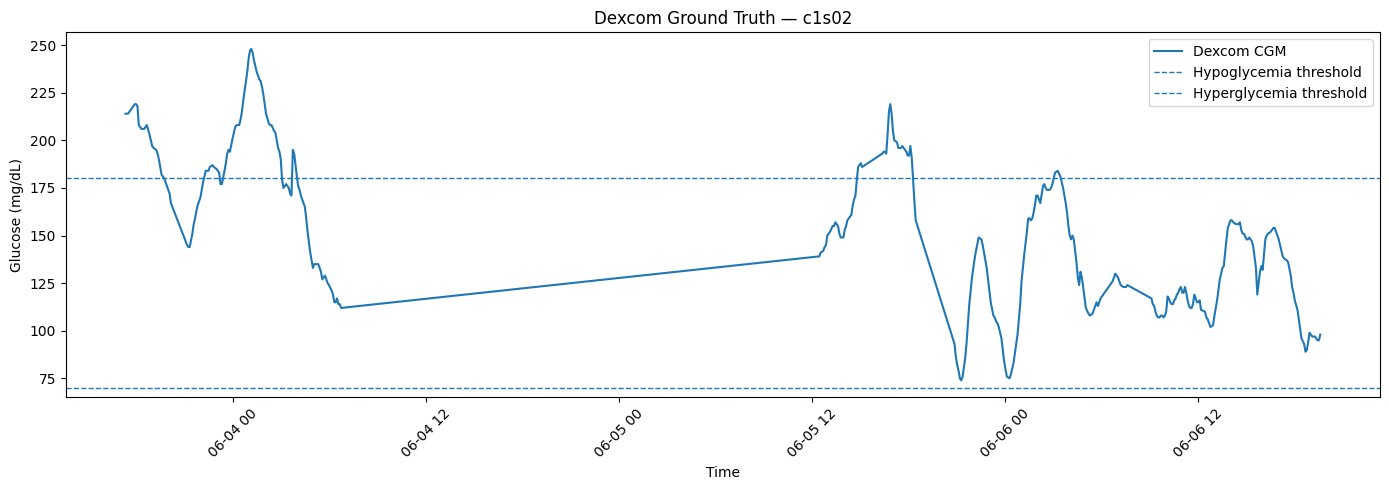

In [ ]:
demo = (
    df[
        df["subject"] ==
        DEMO_SUBJECT
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    demo["timestamp"],
    demo["glucose"],
    linewidth=1.5,
    label="Dexcom CGM"
)

ax.axhline(
    70,
    linestyle="--",
    linewidth=1,
    label="Hypoglycemia threshold"
)

ax.axhline(
    180,
    linestyle="--",
    linewidth=1,
    label="Hyperglycemia threshold"
)

ax.set_title(
    f"Dexcom Ground Truth — {DEMO_SUBJECT}"
)

ax.set_ylabel(
    "Glucose (mg/dL)"
)

ax.set_xlabel(
    "Time"
)

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

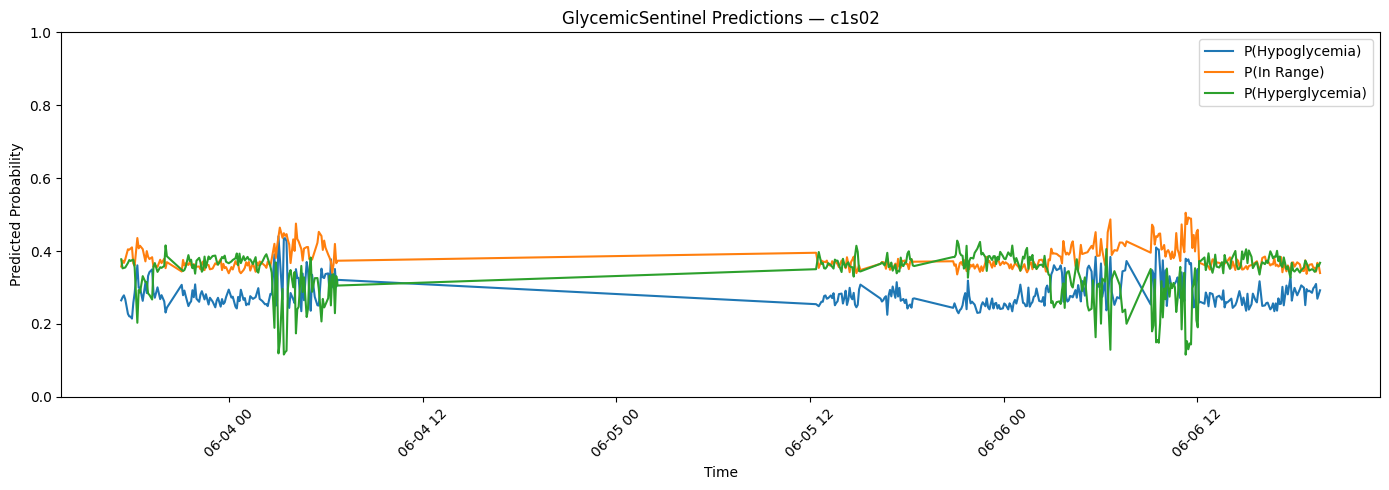

In [ ]:
fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    demo["timestamp"],
    demo["p_hypo"],
    label="P(Hypoglycemia)"
)

ax.plot(
    demo["timestamp"],
    demo["p_normal"],
    label="P(In Range)"
)

ax.plot(
    demo["timestamp"],
    demo["p_hyper"],
    label="P(Hyperglycemia)"
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    f"GlycemicSentinel Predictions — {DEMO_SUBJECT}"
)

ax.set_ylabel(
    "Predicted Probability"
)

ax.set_xlabel(
    "Time"
)

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
errors = (
    df[
        ~df["correct"]
    ]
    .copy()
)

errors = errors.sort_values(
    "confidence",
    ascending=False
)

print(
    "Incorrect predictions:",
    len(errors)
)

print(
    "Error rate:",
    round(
        len(errors) / len(df),
        4
    )
)

display(
    errors[
        [
            "subject",
            "timestamp",
            "glucose",
            "actual_label",
            "predicted_label",
            "confidence",
            "p_hypo",
            "p_normal",
            "p_hyper"
        ]
    ].head(20)
)

Incorrect predictions: 1788
Error rate: 0.4651


,subject,timestamp,glucose,actual_label,predicted_label,confidence,p_hypo,p_normal,p_hyper
3403,c2s05,2022-12-11 07:04:58,66.0,Hypoglycemia,In Range,0.510518,0.378556,0.510518,0.110927
1247,c1s04,2022-06-18 00:34:29,144.0,In Range,Hyperglycemia,0.502514,0.177307,0.320179,0.502514
3404,c2s05,2022-12-11 07:09:59,69.0,Hypoglycemia,In Range,0.496207,0.369517,0.496207,0.134276
2387,c2s02,2022-10-12 22:48:22,66.0,Hypoglycemia,In Range,0.493211,0.390180,0.493211,0.116609
1253,c1s04,2022-06-18 01:09:29,115.0,In Range,Hyperglycemia,0.490143,0.180487,0.329370,0.490143
1252,c1s04,2022-06-18 01:04:29,117.0,In Range,Hyperglycemia,0.489755,0.166432,0.343813,0.489755
1251,c1s04,2022-06-18 00:59:29,119.0,In Range,Hyperglycemia,0.488075,0.172424,0.339501,0.488075
2759,c2s03,2022-10-20 05:17:48,174.0,In Range,Hypoglycemia,0.485732,0.485732,0.422299,0.091969
2751,c2s03,2022-10-20 04:32:48,178.0,In Range,Hypoglycemia,0.484118,0.484118,0.424614,0.091269
1250,c1s04,2022-06-18 00:54:28,122.0,In Range,Hyperglycemia,0.479279,0.169785,0.350936,0.479279


In [ ]:
error_matrix = pd.crosstab(
    df["actual_label"],
    df["predicted_label"],
    normalize="index"
)

display(
    error_matrix.round(3)
)

predicted_label,Hyperglycemia,Hypoglycemia,In Range
actual_label,,,
Hyperglycemia,0.499,0.014,0.487
Hypoglycemia,0.231,0.077,0.692
In Range,0.423,0.009,0.568


In [ ]:
replay = df[
    [
        "subject",
        "timestamp",
        "glucose",
        "actual_label",
        "predicted_label",
        "p_hypo",
        "p_normal",
        "p_hyper",
        "confidence",
        "correct"
    ]
].copy()

# JSON needs strings, not pandas timestamps
replay["timestamp"] = (
    replay["timestamp"]
    .astype(str)
)

REPLAY_CSV = (
    RESULT_DIR /
    "glycemic_sentinel_replay.csv"
)

REPLAY_JSON = (
    RESULT_DIR /
    "glycemic_sentinel_replay.json"
)

replay.to_csv(
    REPLAY_CSV,
    index=False
)

replay.to_json(
    REPLAY_JSON,
    orient="records",
    indent=2
)

print("Saved:")
print(REPLAY_CSV)
print(REPLAY_JSON)

Saved:
/content/drive/MyDrive/GlycemicSentinel/results/glycemic_sentinel_replay.csv
/content/drive/MyDrive/GlycemicSentinel/results/glycemic_sentinel_replay.json


In [ ]:
with open(
    REPLAY_JSON,
    "r"
) as f:

    replay_data = json.load(f)

print(
    json.dumps(
        replay_data[0],
        indent=2
    )
)

{
  "subject": "c1s01",
  "timestamp": "2022-06-26 09:20:03",
  "glucose": 87.0,
  "actual_label": "In Range",
  "predicted_label": "Hyperglycemia",
  "p_hypo": 0.2777823274,
  "p_normal": 0.3600643607,
  "p_hyper": 0.3621533119,
  "confidence": 0.3621533119,
  "correct": false
}


In [ ]:
prob_cols = [
    "p_hypo",
    "p_normal",
    "p_hyper"
]

probs = replay[prob_cols].to_numpy()

# Highest and second-highest probabilities
sorted_probs = np.sort(
    probs,
    axis=1
)

replay["probability_margin"] = (
    sorted_probs[:, -1]
    -
    sorted_probs[:, -2]
)

# This is a UI/replay confidence rule,
# NOT a replacement for the original research prediction.
CONFIDENCE_THRESHOLD = 0.45
MARGIN_THRESHOLD = 0.05

replay["display_prediction"] = (
    replay["predicted_label"]
)

uncertain = (
    (replay["confidence"] < CONFIDENCE_THRESHOLD)
    |
    (replay["probability_margin"] < MARGIN_THRESHOLD)
)

replay.loc[
    uncertain,
    "display_prediction"
] = "Uncertain"

In [ ]:
display(
    replay[
        [
            "glucose",
            "actual_label",
            "predicted_label",
            "display_prediction",
            "confidence",
            "probability_margin",
            "correct"
        ]
    ].head(20)
)

,glucose,actual_label,predicted_label,display_prediction,confidence,probability_margin,correct
0,87.0,In Range,Hyperglycemia,Uncertain,0.362153,0.002089,False
1,80.0,In Range,Hyperglycemia,Uncertain,0.363838,0.010626,False
2,73.0,In Range,Hyperglycemia,Uncertain,0.350606,0.006022,False
3,66.0,Hypoglycemia,In Range,Uncertain,0.357073,0.000859,False
4,63.0,Hypoglycemia,Hyperglycemia,Uncertain,0.361372,0.004563,False
5,63.0,Hypoglycemia,Hyperglycemia,Uncertain,0.383586,0.027373,False
6,73.0,In Range,In Range,Uncertain,0.384061,0.029806,True
7,89.0,In Range,Hyperglycemia,Uncertain,0.366792,0.012780,False
8,117.0,In Range,In Range,Uncertain,0.369953,0.009189,True
9,142.0,In Range,Hyperglycemia,Uncertain,0.363343,0.000012,False
